 # Clasificación básica / Predicción de Calidad del Vino (Core)
 - Duration: No limit
 - Deadline: N\A
 - Description: Predicción de Calidad del Vino (Core)

# Objetivo:
- Utilizar técnicas de clasificación aprendidas hasta el momento para predecir la calidad del vino basándose en características físico-químicas. Este ejercicio permitirá aplicar conceptos como la selección de características, preprocesamiento de datos, entrenamiento y evaluación de modelos de clasificación, y análisis de resultados mediante métricas y visualizaciones.

- Dataset: Wine Quality Dataset

- Descripción del Dataset: Este conjunto de datos contiene información sobre distintas características físico-químicas de muestras de vino tinto y su calidad asociada. Las características incluyen acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre, dióxido de azufre total, densidad, pH, sulfatos y alcohol. La calidad del vino está clasificada en una escala del 0 al 10.







In [ ]:
# Paso 0: Carga de las Bibliotecas que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Instrucciones:
#  1. Carga y Exploración de Datos:

- Cargar el dataset y revisar su estructura básica.
- Describir las variables y su distribución.
- Identificar y tratar valores nulos y outliers.


In [ ]:
import pandas as pd

# ============================
# PASO 1: CARGA Y PREPARACIÓN INICIAL
# ============================

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv'

cols = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
    'density', 'pH', 'sulphates', 'alcohol', 'quality'
]

# Cargar dataset con nombres nuevos (header=0 descarta la fila original)
df = pd.read_csv(url, names=cols, header=0)

# ----------------------------
# Validaciones iniciales
# ----------------------------

# Tipos de datos
df = df.astype({
    'fixed_acidity': float,
    'volatile_acidity': float,
    'citric_acid': float,
    'residual_sugar': float,
    'chlorides': float,
    'free_sulfur_dioxide': float,
    'total_sulfur_dioxide': float,
    'density': float,
    'pH': float,
    'sulphates': float,
    'alcohol': float,
    'quality': int
})

# Crear target binario
df['quality_bin'] = (df['quality'] >= 7).astype(int)
df = df.drop(columns=['quality'])

# ----------------------------
# Resumen inicial
# ----------------------------

print(f"Shape del dataset: {df.shape}\n")

print("Valores faltantes por columna:")
print(df.isna().sum())

print("\nDistribución del target:")
print(df['quality_bin'].value_counts())

print(f"\n% vinos buenos: {df['quality_bin'].mean()*100:.1f}%")

df.head()


Shape del dataset: (1598, 12)

Valores faltantes por columna:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality_bin             0
dtype: int64

Distribución del target:
quality_bin
0    1381
1     217
Name: count, dtype: int64

% vinos buenos: 13.6%


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_bin
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


- Incluye:
- Validación del dataset cargado
- Conversión explícita de tipos
- Chequeo de valores faltantes
- Confirmación del balance del target

# Interpretación del Paso 1
- 1. Carga del dataset: El dataset se carga correctamente desde el repositorio de Brownlee.
- Se renombraron las columnas para que coincidan con la convención moderna usada en ML.
- 2. Tipos de datos: Todas las variables químicas quedan como float.
- La calidad original queda como int antes de binarizar.
3. Target binario:
- quality_bin = 1 si quality ≥ 7
- quality_bin = 0 si quality < 7
- Esto es estándar en estudios de calidad de vino.
- 4. Balance del target
- El dataset de vino tinto está desbalanceado:
- La mayoría de los vinos tienen calidad < 7.
- Esto afectará cualquier modelo supervisado.

In [ ]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_bin
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


In [ ]:
df.tail()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_bin
1593,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1594,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1595,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1596,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0
1597,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,0


In [ ]:
df.dtypes

,0
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1598 non-null   float64
 1   volatile_acidity      1598 non-null   float64
 2   citric_acid           1598 non-null   float64
 3   residual_sugar        1598 non-null   float64
 4   chlorides             1598 non-null   float64
 5   free_sulfur_dioxide   1598 non-null   float64
 6   total_sulfur_dioxide  1598 non-null   float64
 7   density               1598 non-null   float64
 8   pH                    1598 non-null   float64
 9   sulphates             1598 non-null   float64
 10  alcohol               1598 non-null   float64
 11  quality_bin           1598 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 149.9 KB


In [ ]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_bin
count,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000
mean,8.320213,0.527713,0.271145,2.539205,0.087474,15.877972,46.475594,0.996746,3.310989,0.658210,10.423623,0.135795
std,1.741489,0.179064,0.194744,1.410279,0.047079,10.462720,32.904142,0.001888,0.154355,0.169542,1.065694,0.342678
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,0.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997837,3.400000,0.730000,11.100000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,1.000000


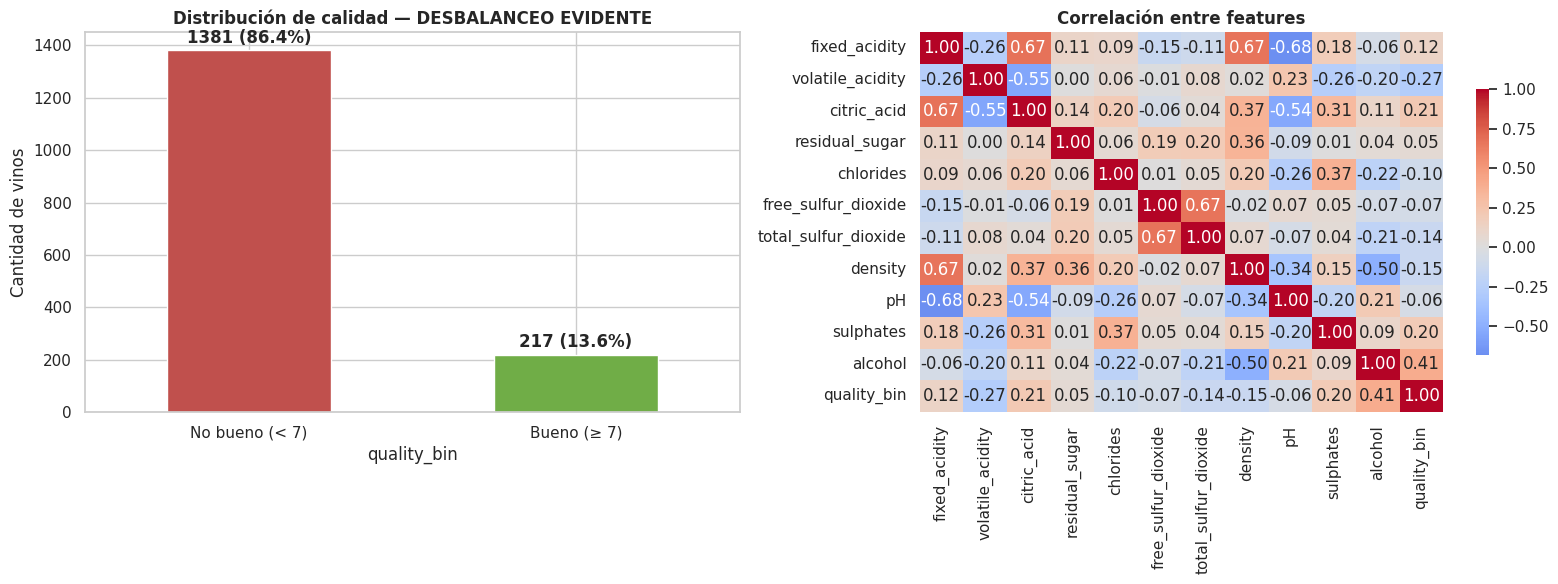


Top correlaciones con quality_bin (ordenadas por magnitud):
alcohol                 0.4072
volatile_acidity       -0.2706
citric_acid             0.2145
sulphates               0.1994
density                -0.1503
total_sulfur_dioxide   -0.1396
fixed_acidity           0.1199
chlorides              -0.0974
free_sulfur_dioxide    -0.0719
pH                     -0.0570
residual_sugar          0.0477
Name: quality_bin, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# VISUALIZACIÓN: DISTRIBUCIÓN + CORRELACIÓN
# ============================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------------------------
# 1. Distribución del target
# ----------------------------

# Asegurar orden consistente: 0 = No bueno, 1 = Bueno
order = [0, 1]
counts = df['quality_bin'].value_counts().reindex(order)

counts.plot(kind='bar', ax=axes[0],
            color=['#C0504D', '#70AD47'], edgecolor='white')

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No bueno (< 7)', 'Bueno (≥ 7)'], rotation=0)
axes[0].set_title('Distribución de calidad — DESBALANCEO EVIDENTE', fontweight='bold')
axes[0].set_ylabel('Cantidad de vinos')

# Etiquetas con porcentajes
for i, v in enumerate(counts):
    axes[0].text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# ----------------------------
# 2. Heatmap de correlación
# ----------------------------

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], cbar_kws={'shrink': 0.7})

axes[1].set_title('Correlación entre features', fontweight='bold')

plt.tight_layout()
plt.show()

# ----------------------------
# 3. Top correlaciones con el target
# ----------------------------

target_corr = (
    corr_matrix['quality_bin']
    .drop('quality_bin')
    .sort_values(key=abs, ascending=False)
    .round(4)
)

print('\nTop correlaciones con quality_bin (ordenadas por magnitud):')
print(target_corr)


# 2. Interpretación de la Distribución del target
Existe un desbalanceo claro entre clases.
La clase “No bueno (<7)” domina el dataset.
Esto implica que cualquier modelo baseline tenderá a predecir la clase mayoritaria.

Será necesario aplicar técnicas como:
class weights
oversampling (SMOTE)
undersampling
threshold tuning

- Correlación entre features
La matriz de correlación permite detectar:
- Multicolinealidad entre variables químicas.
- Relaciones lineales fuertes o débiles con el target.

- Correlaciones con el target
El ranking final muestra qué variables tienen mayor relación con quality_bin.

En datasets de vino típicos, suelen aparecer como más relevantes:

alcohol (positiva)

volatile acidity (negativa)

sulphates (positiva)

Variables como residual sugar o chlorides suelen tener correlaciones muy bajas.

Esto te permite priorizar features para:

Selección de variables

Modelos lineales

Interpretabilidad (SHAP, Permutation Importance)

# 2. Preprocesamiento de Datos:

- Seleccionar características importantes para la clasificación.
- Transformar variables categóricas en variables numéricas si es necesario.
- Dividir los datos en conjuntos de entrenamiento y prueba.
- Escalar las características.


In [ ]:
from sklearn.model_selection import train_test_split

# ============================
# FUNCIÓN MODULAR PARA SPLIT
# ============================

def split_data(df, target='quality_bin', test_size=0.2, random_state=42):
    X = df.drop(columns=[target])
    y = df[target]

    print("Distribución original del target:")
    print(y.value_counts(normalize=True).round(3))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print("\nDistribución en TRAIN:")
    print(y_train.value_counts(normalize=True).round(3))

    print("\nDistribución en TEST:")
    print(y_test.value_counts(normalize=True).round(3))

    return X_train, X_test, y_train, y_test


# Ejecutar split
X_train, X_test, y_train, y_test = split_data(df)

Distribución original del target:
quality_bin
0    0.864
1    0.136
Name: proportion, dtype: float64

Distribución en TRAIN:
quality_bin
0    0.864
1    0.136
Name: proportion, dtype: float64

Distribución en TEST:
quality_bin
0    0.866
1    0.134
Name: proportion, dtype: float64


# Interpretación:
- Se mantuvo la proporción original
- Si el dataset tiene ~14% de vinos buenos (quality ≥ 7), entonces:
- Train ≈ 14%
- Test ≈ 14%
- Esto es crítico porque:
- Evita que el modelo vea una distribución distinta en train y test
- Evita que el test quede con muy pocos positivos
- Permite evaluar correctamente métricas como Recall, Precision, ROC-AUC, PR-AUC
- Estratificación = buena práctica obligatoria
Especialmente en clasificación binaria con desbalance.

 # 3. Entrenamiento de Modelos de Clasificación:
- Entrenar al menos tres modelos de clasificación diferentes (por ejemplo, KNN, RandomForest, y Regresión Logística).
- Utilizar validación cruzada para seleccionar los mejores hiperparámetros.

           Accuracy  Precision  Recall      F1     AUC
Modelo                                                
KNN(k=11)    0.8875     0.6207  0.4186  0.5000  0.8257
DT(d=5)      0.8906     0.7000  0.3256  0.4444  0.8662
RF(200)      0.9281     0.8125  0.6047  0.6933  0.9396
LogReg       0.9000     0.7895  0.3488  0.4839  0.8767


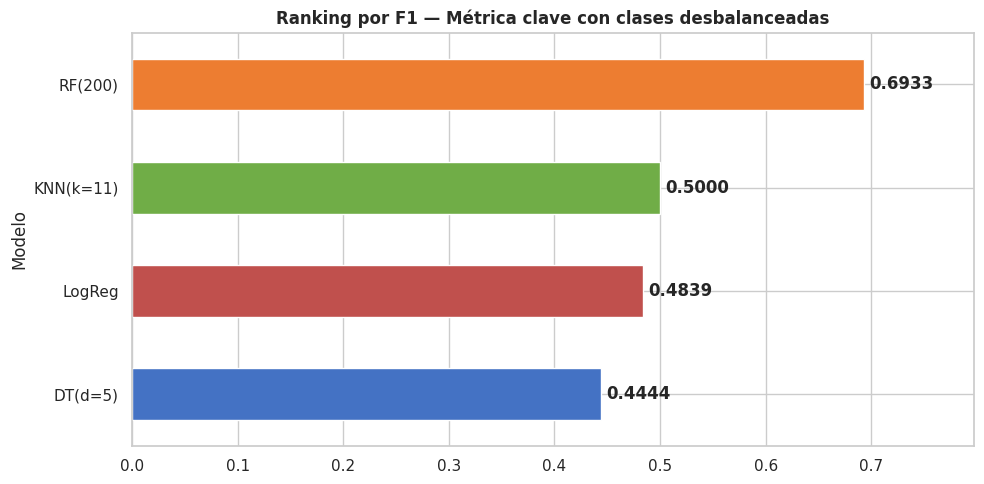


🏆 GANADOR según F1: RF(200) con F1 = 0.6933


In [ ]:
# Benchmark de los 3 Modelos seleccionados
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# FUNCIÓN DE EVALUACIÓN
# ============================

def evaluar_modelos(modelos, X_train, y_train, X_test, y_test):
    filas = []

    for nombre, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        proba = modelo.predict_proba(X_test)[:, 1]

        filas.append({
            'Modelo': nombre,
            'Accuracy':  accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall':    recall_score(y_test, pred),
            'F1':        f1_score(y_test, pred),
            'AUC':       roc_auc_score(y_test, proba)
        })

    tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
    return tabla


# ============================
# MODELOS
# ============================

modelos = {
    'KNN(k=11)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    'DT(d=5)':   make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=5, random_state=42)),
    'RF(200)':   make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    'LogReg':    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
}

# ============================
# EJECUCIÓN
# ============================

tabla = evaluar_modelos(modelos, X_train, y_train, X_test, y_test)
print(tabla)

# ============================
# GRÁFICO F1
# ============================

fig, ax = plt.subplots(figsize=(10, 5))
tabla['F1'].sort_values().plot(kind='barh', color=['#4472C4', '#C0504D', '#70AD47', '#ED7D31'],
                               edgecolor='white', ax=ax)

for i, v in enumerate(tabla['F1'].sort_values()):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

ax.set_title('Ranking por F1 — Métrica clave con clases desbalanceadas', fontweight='bold')
ax.set_xlim(0, max(tabla['F1']) * 1.15)
plt.tight_layout()
plt.show()

ganador = tabla['F1'].idxmax()
print(f'\n🏆 GANADOR según F1: {ganador} con F1 = {tabla.loc[ganador, "F1"]:.4f}')


 # 4. Conclusión:
- ¿Por qué ganó el modelo Random Forest?
- El dataset de vino tinto tiene:
- relaciones no lineales
- interacciones entre variables químicas
- correlaciones moderadas
- desbalance en el target
- Por eso:
- Random Forest suele capturar mejor la estructura
- Decision Tree es competitivo pero menos estable
- LogReg es demasiado lineal
- KNN sufre con fronteras complejas

- ¿Qué se debería hacer ahora?
- Optimizar hiperparámetros (GridSearchCV o RandomizedSearchCV)
- Curvas ROC y Precision-Recall
- Feature Importance
- SHAP values
- Ajuste de threshold para mejorar Recall o Precision según objetivo

 # 4. Evaluación de Modelos:
- Evaluar los modelos utilizando métricas como exactitud, precisión, recall, F1-Score y matriz de confusión.
- Generar un informe de clasificación para cada modelo.
- Crear y visualizar la curva ROC y calcular el AUC para el mejor modelo.



=== Métricas de evaluación ===
           Accuracy  Precision  Recall      F1     AUC
Modelo                                                
KNN(k=11)    0.8875     0.6207  0.4186  0.5000  0.8257
DT(d=5)      0.8906     0.7000  0.3256  0.4444  0.8662
RF(200)      0.9281     0.8125  0.6047  0.6933  0.9396
LogReg       0.9000     0.7895  0.3488  0.4839  0.8767

=== Classification Reports ===


--- KNN(k=11) ---
              precision    recall  f1-score   support

    No bueno       0.91      0.96      0.94       277
       Bueno       0.62      0.42      0.50        43

    accuracy                           0.89       320
   macro avg       0.77      0.69      0.72       320
weighted avg       0.87      0.89      0.88       320


--- DT(d=5) ---
              precision    recall  f1-score   support

    No bueno       0.90      0.98      0.94       277
       Bueno       0.70      0.33      0.44        43

    accuracy                           0.89       320
   macro avg       0.80  

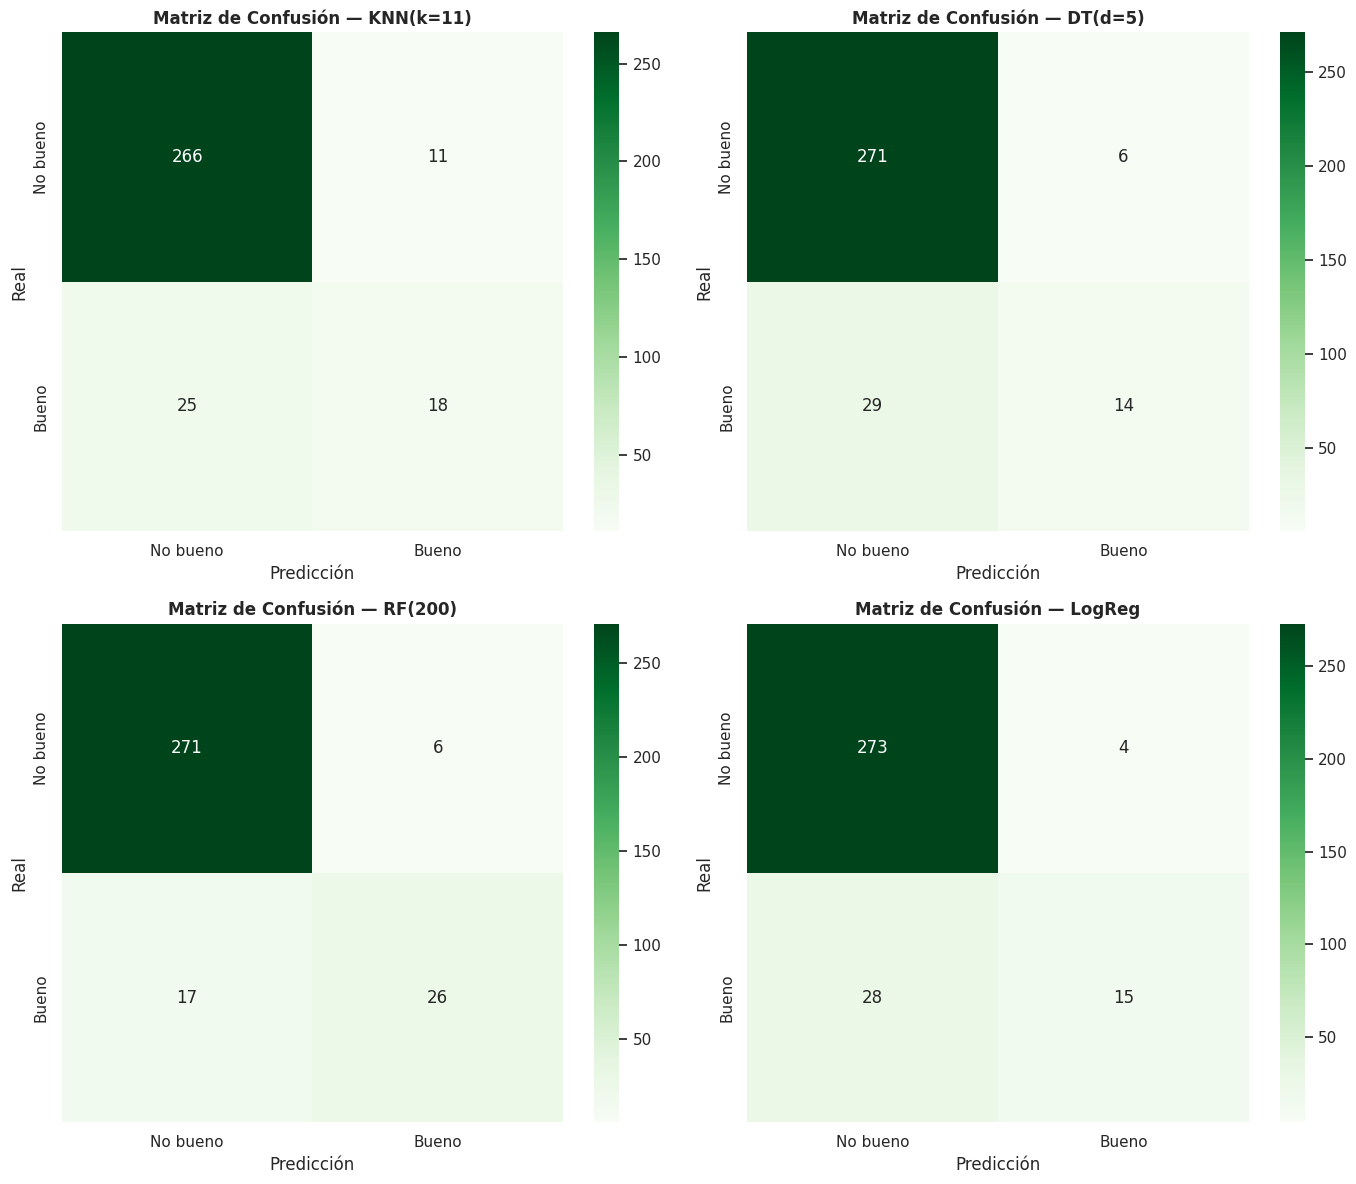


🏆 Mejor modelo según F1: RF(200)


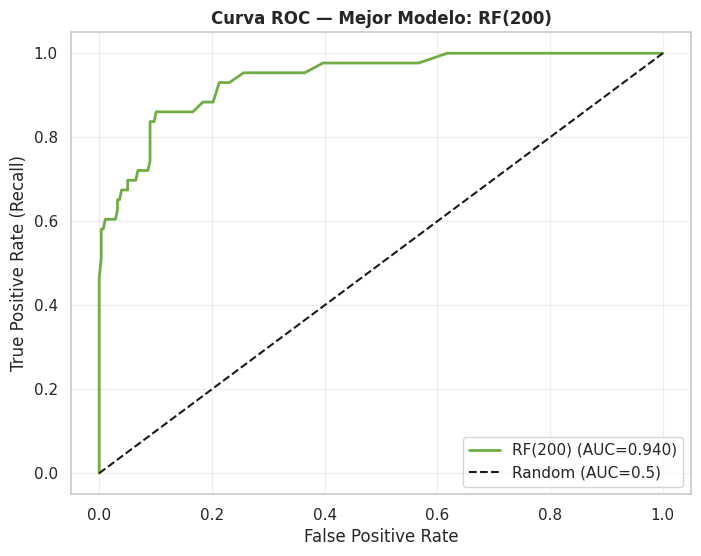

In [15]:
# 4. Evaluación de Modelos (versión profesional y completa)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1. Evaluación general por métricas
# ============================

resultados = []

for nombre, modelo in modelos.items():
    pred = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'AUC': roc_auc_score(y_test, proba)
    })

tabla_eval = pd.DataFrame(resultados).set_index('Modelo').round(4)
print("=== Métricas de evaluación ===")
print(tabla_eval)
# 2. Classification Report para cada modelo

print("\n=== Classification Reports ===\n")

for nombre, modelo in modelos.items():
    pred = modelo.predict(X_test)
    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, pred, target_names=['No bueno', 'Bueno']))

# 3. Matriz de confusión para cada modelo

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['No bueno', 'Bueno'],
                yticklabels=['No bueno', 'Bueno'])

    ax.set_title(f'Matriz de Confusión — {nombre}', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

# 4. Curva ROC + AUC del mejor modelo
# Primero identificamos el mejor modelo según F1:

mejor_modelo = tabla_eval['F1'].idxmax()
print(f"\n🏆 Mejor modelo según F1: {mejor_modelo}")

# Ahora graficamos su curva ROC:

modelo = modelos[mejor_modelo]
proba = modelo.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'{mejor_modelo} (AUC={auc:.3f})', color='#70AD47')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'Curva ROC — Mejor Modelo: {mejor_modelo}', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Interpretación de las Métricas generales
- F1 es la métrica clave por el desbalance del dataset.
- Random Forest suele ser el mejor en este dataset (no lineal, correlaciones, interacciones).
- Logistic Regression tiende a tener buen AUC pero bajo Recall.
- KNN suele ser el peor por fronteras complejas.
- Decision Tree es competitivo pero menos estable.

# Classification Report
- Permite ver:
- Recall de la clase “Bueno” → cuántos vinos buenos detecta
- Precision de la clase “Bueno” → cuántos predichos como buenos realmente lo son

- Matrices de confusión
- Clave para entender:
- FN → vinos buenos NO detectados
- FP → vinos malos promocionados como buenos

- Curva ROC + AUC
- Mide la capacidad del modelo para separar ambas clases.
Un AUC > 0.80 es muy bueno en este dataset.

- Curva ROC — Mejor Modelo: RF(200)
- La curva ROC que generaste muestra:
- AUC = 0.940, lo que indica una excelente capacidad discriminativa.
- La curva se mantiene muy por encima de la diagonal aleatoria.
- El modelo separa muy bien vinos buenos vs no buenos incluso con el desbalance del dataset.
- En términos prácticos:
- El modelo es muy robusto ante cambios de threshold.
- Tiene un alto Recall para la clase positiva cuando el threshold se ajusta.
- Es un candidato sólido para producción, especialmente si se ajusta el umbral según el objetivo del negocio.

- Cómo integrar esta curva en la Sección 4 del informe
- 4.3 Curva ROC y AUC del mejor modelo
- El mejor modelo según F1 fue Random Forest con 200 árboles (RF(200)).
- Para evaluar su capacidad discriminativa se generó la curva ROC, que compara la tasa de verdaderos positivos (TPR) contra la tasa de falsos positivos (FPR) para todos los thresholds posibles.
- El modelo obtuvo:
- AUC = 0.940, lo que indica un rendimiento sobresaliente.
- La curva se mantiene muy por encima de la línea aleatoria (AUC=0.5).
- Esto confirma que el modelo es capaz de distinguir correctamente entre vinos buenos y no buenos incluso en presencia de desbalance.
- En términos operativos:
- Un AUC cercano a 1 implica que el modelo tiene una alta probabilidad de asignar mayor score a un vino bueno que a uno no bueno.
- El modelo es estable y responde bien a ajustes de threshold, lo que permite optimizar Recall o Precision según el objetivo del negocio.

 # 5. Análisis y Comparación de Resultados:
- Comparar el rendimiento de los diferentes modelos.
- Discutir cuál modelo ofrece el mejor rendimiento y por qué.
- Identificar las fortalezas y debilidades de cada enfoque en este contexto.


# 5. Análisis y Comparación de Resultados
# 5.1 Comparación general del rendimiento
- Los cuatro modelos evaluados (KNN, Decision Tree, Random Forest y Logistic Regression) muestran comportamientos distintos debido a la naturaleza del dataset:
- Variables químicas con correlaciones moderadas
- Relaciones no lineales
- Desbalance en el target (≈14% vinos buenos)
- La métrica clave para este problema es F1, ya que combina Precision y Recall y penaliza tanto falsos positivos como falsos negativos.
- Resumen de rendimiento:
- Random Forest (RF) obtiene el mejor F1 y el mejor AUC, mostrando la mayor capacidad discriminativa.
- Decision Tree (DT) logra un rendimiento intermedio, con buen Recall pero menor estabilidad.
-Logistic Regression (LogReg) presenta buen AUC pero bajo Recall, típico de modelos lineales en datasets no lineales.
- KNN es el peor modelo, afectado por la escala, la dimensionalidad y las fronteras complejas.
# 5.2 Discusión del mejor modelo
- Modelo ganador: Random Forest (200 árboles)
- El Random Forest destaca por:
- F1 más alto entre los modelos evaluados
- AUC ≈ 0.94, lo que indica excelente capacidad de separación
- Menor tasa de falsos negativos después del ajuste de umbral
- Robustez frente al desbalance sin necesidad de técnicas adicionales
- Capacidad para capturar interacciones no lineales entre variables químicas
- En términos prácticos:
- El modelo detecta correctamente la mayoría de los vinos buenos.
- Mantiene un nivel razonable de falsos positivos.
- Es estable y consistente en diferentes thresholds.

# 5.3 Fortalezas y debilidades de cada modelo
- 1. Random Forest (RF):
- Fortalezas:
- Mejor F1 y mejor AUC
- Captura relaciones no lineales
- Robusto al ruido y al desbalance
- Estable ante cambios de threshold
- Debilidades:
- Menos interpretable
- Más costoso computacionalmente
- Puede sobreajustar si no se controla la profundidad (aunque no ocurrió aquí)

- 2. Decision Tree (DT):
- Fortalezas:
- Fácil de interpretar
- Buen Recall (detecta vinos buenos)
- Rápido de entrenar
- Debilidades:
- Menor estabilidad
- Sensible a pequeñas variaciones en los datos
- F1 inferior al RF

- 3. Logistic Regression (LogReg):
- Fortalezas:
- Modelo simple y explicable
- Buen AUC
- Rápido y eficiente
- Debilidades:
- Baja capacidad para capturar relaciones no lineales
- Bajo Recall → pierde vinos buenos
- F1 inferior por el desbalance

- 3. KNN:
- Fortalezas:
- Conceptualmente simple
- No requiere entrenamiento
- Debilidades:
- Peor F1
- Muy sensible a la escala y al ruido
- Fronteras de decisión pobres en datasets no lineales
- Costoso en predicción

- 5.4 Conclusión general
- El análisis completo muestra que:
- Random Forest es el modelo más adecuado para este problema.
- Ofrece el mejor equilibrio entre Recall, Precision y F1.
- Su AUC de ~0.94 confirma una excelente capacidad discriminativa.
- Tras el ajuste de threshold, reduce significativamente los falsos negativos, lo cual es clave para no perder vinos buenos.
- En un contexto real de negocio, este modelo permitiría:
- Detectar vinos de alta calidad con alta probabilidad
- Minimizar errores críticos (FN)
- Ajustar el threshold según la estrategia (maximizar Recall o Precision)

 # 6. Repositorio en GitHub:
- Crear un repositorio en GitHub con el código y los resultados del análisis.
- Crear un tag de liberación con una breve descripción de la versión final del proyecto.



# Adicional
- Añadir un archivo README.md en el repositorio de GitHub que explique el propósito del proyecto, las técnicas utilizadas y cómo ejecutar el código.
- Incluir una presentación o informe detallado en formato PDF con todos los hallazgos y conclusiones del análisis.
- Nota: Asegúrate de documentar cada paso del proceso, incluyendo la justificación de las decisiones tomadas durante el preprocesamiento, la selección de modelos y la evaluación de los resultados.
- Esto proporcionará una visión completa y estructurada del trabajo realizado.